# **CNN y Transfer Learning para clasificación de células sanguíneas**

Este notebook presenta el desarrollo de un ejercicio de CNN y Transfer Learning aplicado al dataset **BloodMNIST**, compuesto por imágenes de microscopía de células sanguíneas individuales clasificadas en **8 categorías**. Como punto de partida se tomó la guía trabajada en clase con PneumoniaMNIST, adaptando el procedimiento a un nuevo dataset y a un problema de clasificación multiclase.

A lo largo del notebook se realizan los siguientes pasos:

1. **Carga y exploración de BloodMNIST**, incluyendo la visualización de imágenes y la distribución de sus clases.
2. **Diseño y entrenamiento de una CNN**, incorporando Batch Normalization, Dropout y un mayor número de filtros.
3. **Experimentación con el learning rate y el uso de un scheduler**, para observar su efecto durante el entrenamiento.
4. **Comparación de diferentes niveles de data augmentation**, evaluando cómo afectan el rendimiento del modelo.
5. **Adaptación del pipeline a BloodMNIST**, considerando sus 8 clases y las características de sus imágenes.
6. **Aplicación de Transfer Learning con ResNet18**, seguida del uso de Grad-CAM para interpretar las regiones de la imagen que influyen en las predicciones.
7. **Evaluación mediante curvas ROC y calibración de probabilidades**, para analizar el comportamiento de las predicciones del modelo.
8. **Análisis de las curvas de entrenamiento y validación**, con el fin de identificar posibles señales de overfitting.


## **1. ¿Qué es una CNN y por qué la uso?**

Una **CNN (Red Neuronal Convolucional)** es un tipo de red especialmente adecuada para trabajar con imágenes. A diferencia de una red neuronal completamente conectada, una CNN utiliza **filtros convolucionales** que recorren la imagen para identificar características locales, como bordes, texturas y formas.

A medida que se avanza por las distintas capas de la red, estas características simples se combinan para reconocer patrones cada vez más complejos. En este ejercicio, la CNN se utiliza para aprender las características visuales presentes en las imágenes de células sanguíneas y clasificarlas en una de las **8 categorías de BloodMNIST**.

### Componentes principales de la CNN

* **Conv2D:** aplica filtros sobre la imagen para detectar y aprender características visuales.

* **BatchNorm:** normaliza las activaciones generadas durante el entrenamiento, ayudando a que este sea más estable.

* **ReLU:** introduce no linealidad en la red, permitiendo aprender relaciones y patrones más complejos.

* **MaxPool:** reduce progresivamente las dimensiones espaciales de las características obtenidas, conservando la información más relevante.

* **AdaptiveAvgPool:** ajusta la salida a un tamaño determinado antes de pasar a la etapa de clasificación.

* **Dropout:** desactiva aleatoriamente una parte de las neuronas durante el entrenamiento, reduciendo la dependencia de características específicas y ayudando a disminuir el riesgo de overfitting.

## **2. Preparación del entorno**

En esta sección se instalan las librerías necesarias para trabajar con el dataset, construir y entrenar los modelos, evaluar sus resultados y generar las visualizaciones correspondientes.

In [ ]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

In [ ]:
import random
import numpy as np
import torch

# Fijamos una semilla para mantener la reproducibilidad de los experimentos
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## **3. Carga y preparación del dataset BloodMNIST**

En esta sección se carga BloodMNIST y se preparan los conjuntos de entrenamiento, validación y prueba que se utilizarán durante el desarrollo del ejercicio.

In [ ]:
import medmnist
from medmnist import INFO

data_flag = "bloodmnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])
n_channels = info["n_channels"]
num_classes = len(info["label"])

print("Tarea:", info["task"])
print("Canales de entrada:", n_channels)
print("Número de clases:", num_classes)
print("Clases:", info["label"])

Tarea: multi-class
Canales de entrada: 3
Número de clases: 8
Clases: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}


Inicialmente se utiliza una transformación básica para convertir las imágenes en tensores. Más adelante se incorporarán distintas técnicas de data augmentation para comparar su efecto en el entrenamiento.

In [ ]:
import torchvision.transforms as T

# Transformación básica de las imágenes a tensores
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)

(11959, 1712, 3421)

### **3.1. Visualización de imágenes del dataset**

Antes de iniciar el entrenamiento, se visualizan algunas imágenes de BloodMNIST para observar las características generales del dataset y verificar sus respectivas etiquetas.


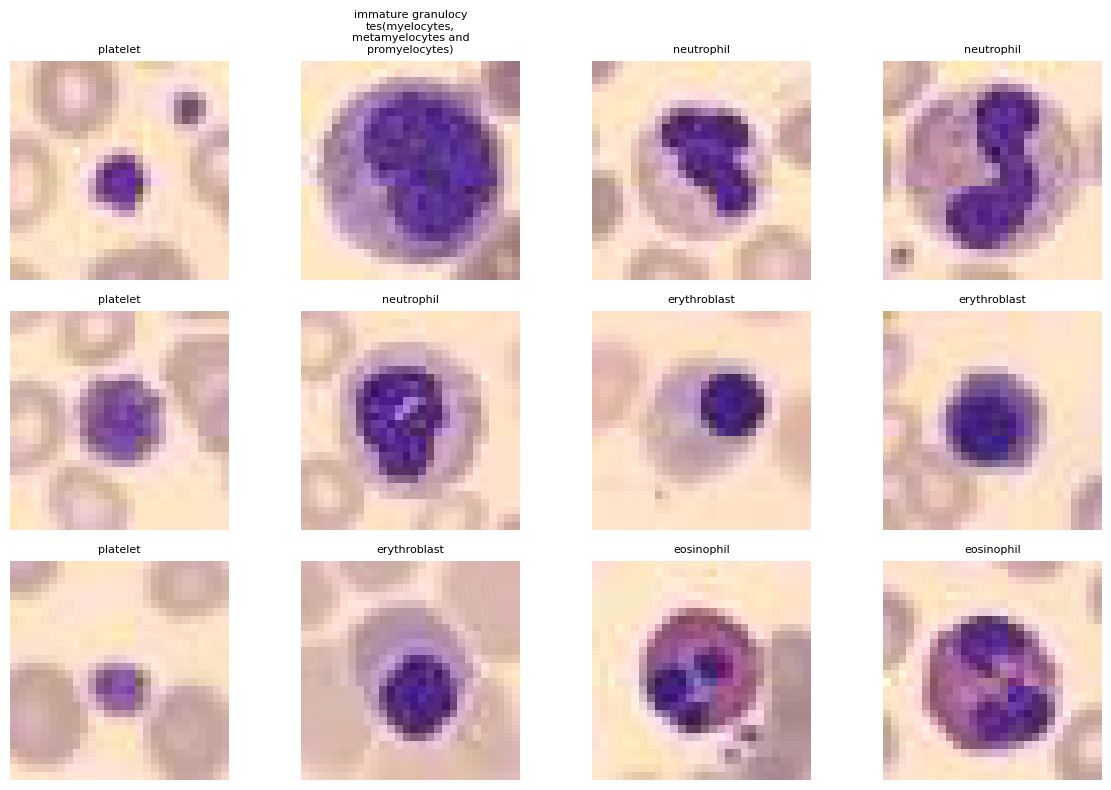

In [ ]:
import matplotlib.pyplot as plt
import textwrap

def show_batch(dataset, n=12):
    plt.figure(figsize=(12, 8))

    for i in range(n):
        x, y = dataset[i]

        plt.subplot(3, 4, i + 1)

        # Convertimos el tensor al formato esperado por Matplotlib
        img = x.permute(1, 2, 0).numpy()
        plt.imshow(img)

        # Mostramos el nombre de la clase en lugar de su número
        class_name = info["label"][str(int(y.item()))]
        class_name = "\n".join(textwrap.wrap(class_name, width=18))
        plt.title(class_name, fontsize=8)

        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

### **3.2. Distribución de las clases**

Se revisa la cantidad de imágenes disponibles para cada clase en el conjunto de entrenamiento. Esto nos permite identificar posibles diferencias en la representación de las categorías antes de entrenar el modelo.

In [ ]:
import numpy as np

# Contamos las imágenes disponibles para cada clase
labels_train = np.array([int(train_dataset[i][1].item()) for i in range(len(train_dataset))])

clases, conteos = np.unique(labels_train, return_counts=True)

for c, n in zip(clases, conteos):
    print(f"Clase {c} ({info['label'][str(c)]}): {n} ejemplos")

Clase 0 (basophil): 852 ejemplos
Clase 1 (eosinophil): 2181 ejemplos
Clase 2 (erythroblast): 1085 ejemplos
Clase 3 (immature granulocytes(myelocytes, metamyelocytes and promyelocytes)): 2026 ejemplos
Clase 4 (lymphocyte): 849 ejemplos
Clase 5 (monocyte): 993 ejemplos
Clase 6 (neutrophil): 2330 ejemplos
Clase 7 (platelet): 1643 ejemplos


**Observación:** La cantidad de imágenes no es igual entre todas las clases. Neutrophil es la categoría con mayor número de ejemplos (2330), mientras que lymphocyte (849) y basophil (852) presentan las cantidades más bajas. Por esta razón, además del accuracy, posteriormente se utilizarán otras métricas para evaluar el desempeño del modelo.

## **4. Preparación de DataLoaders y dispositivo**

Los DataLoaders permiten organizar las imágenes en lotes para utilizarlas durante el entrenamiento y la evaluación. En el conjunto de entrenamiento se activa shuffle para variar el orden de las muestras en cada época. Además, se selecciona automáticamente la GPU cuando está disponible; caso contrario, el procesamiento se realiza en CPU.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

(torch.Size([128, 3, 28, 28]), torch.Size([128, 1]))

## **5. Arquitectura de la CNN propuesta**

Para este ejercicio se utiliza una CNN con tres bloques convolucionales, aumentando progresivamente el número de filtros de **32 a 64 y 128**. Después de cada convolución se aplica **Batch Normalization** y **ReLU**, mientras que las dos primeras etapas incluyen **MaxPooling** para reducir las dimensiones espaciales.

Al final de la extracción de características se utiliza **Adaptive Average Pooling**, seguido de **Dropout** y una capa lineal encargada de generar la salida correspondiente a las **8 clases de BloodMNIST**. La incorporación de Batch Normalization y Dropout busca favorecer un entrenamiento más estable y reducir el riesgo de sobreajuste.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNNMejorada(nn.Module):
    def __init__(self, in_channels, num_classes, dropout_p=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = CNNMejorada(in_channels=n_channels, num_classes=num_classes).to(device)
model_scratch

CNNMejorada(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=8, bias=True)
  )
)

### **5.1. Funciones de entrenamiento y evaluación**

Para entrenar y evaluar la CNN se definen dos funciones principales. La primera realiza el entrenamiento durante una época y calcula la pérdida promedio. La segunda evalúa las predicciones del modelo mediante accuracy y ROC-AUC macro, adaptando la evaluación a las 8 clases.

Para calcular el ROC-AUC multiclase se utiliza el enfoque uno contra el resto (One-vs-Rest, OvR), en el que cada clase se evalúa frente a las demás y posteriormente se obtiene el promedio entre todas las clases.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, clip_value=1.0):
    model.train()
    running_loss = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()

        # Limitamos la norma de los gradientes para mantener estable el entrenamiento
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_value)

        optimizer.step()

        running_loss += loss.item() * x.size(0)
        n += x.size(0)

    return running_loss / n

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    # Convertimos los logits en probabilidades para las 8 clases
    return torch.softmax(logits, dim=1)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = torch.argmax(probs, dim=1)

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs, axis=0)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)

    try:
        auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")

    return acc, auc, y_true, y_pred, y_prob

### **5.2. Entrenamiento de la CNN**

La CNN se entrena durante 20 épocas utilizando **CrossEntropyLoss** como función de pérdida y el optimizador Adam con un learning rate inicial de 3e-4. También se incorpora **weight_decay** como técnica de regularización.

Durante el entrenamiento se utiliza **CosineAnnealingLR**, que reduce progresivamente el learning rate a lo largo de las épocas. Además, se aplica gradient clipping para limitar la norma de los gradientes y contribuir a la estabilidad del entrenamiento.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=3e-4, weight_decay=3e-4)

epochs = 20

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)  # T_max se ajusta al número total de épocas
history_scratch = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)

    #  Calculamos la pérdida de validación para compararla con la de entrenamiento
    model_scratch.eval()
    with torch.no_grad():
        val_losses = []

        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device).long().squeeze(1)
            logits = model_scratch(x)
            val_losses.append(criterion(logits, y).item())

        val_loss = float(np.mean(val_losses))

    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    scheduler.step()

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    lr_actual = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} "
          f"| val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | lr={lr_actual:.6f}")


Epoch 01 | train_loss=1.2742 | val_loss=0.9195 | val_acc=0.6922 | val_auc=0.9608 | lr=0.000298
Epoch 02 | train_loss=0.7356 | val_loss=0.6464 | val_acc=0.8452 | val_auc=0.9778 | lr=0.000293
Epoch 03 | train_loss=0.5541 | val_loss=0.5007 | val_acc=0.8697 | val_auc=0.9826 | lr=0.000284
Epoch 04 | train_loss=0.4695 | val_loss=0.4475 | val_acc=0.8674 | val_auc=0.9852 | lr=0.000271
Epoch 05 | train_loss=0.4198 | val_loss=0.3827 | val_acc=0.8750 | val_auc=0.9876 | lr=0.000256
Epoch 06 | train_loss=0.3801 | val_loss=0.4169 | val_acc=0.8651 | val_auc=0.9866 | lr=0.000238
Epoch 07 | train_loss=0.3538 | val_loss=0.3883 | val_acc=0.8697 | val_auc=0.9887 | lr=0.000218
Epoch 08 | train_loss=0.3313 | val_loss=0.3422 | val_acc=0.8732 | val_auc=0.9901 | lr=0.000196
Epoch 09 | train_loss=0.3144 | val_loss=0.3158 | val_acc=0.9007 | val_auc=0.9918 | lr=0.000173
Epoch 10 | train_loss=0.2961 | val_loss=0.2732 | val_acc=0.9141 | val_auc=0.9921 | lr=0.000150
Epoch 11 | train_loss=0.2852 | val_loss=0.2814 | v

### **5.3. Análisis de las curvas de aprendizaje**

Para analizar el comportamiento de la CNN durante el entrenamiento, se comparan las pérdidas de entrenamiento y validación a lo largo de las 20 épocas. Una separación progresiva entre ambas curvas, especialmente si la pérdida de entrenamiento continúa disminuyendo mientras la de validación aumenta, puede ser una señal de overfitting.

También se muestran el accuracy y el ROC-AUC obtenidos sobre el conjunto de validación para observar su evolución durante el entrenamiento.

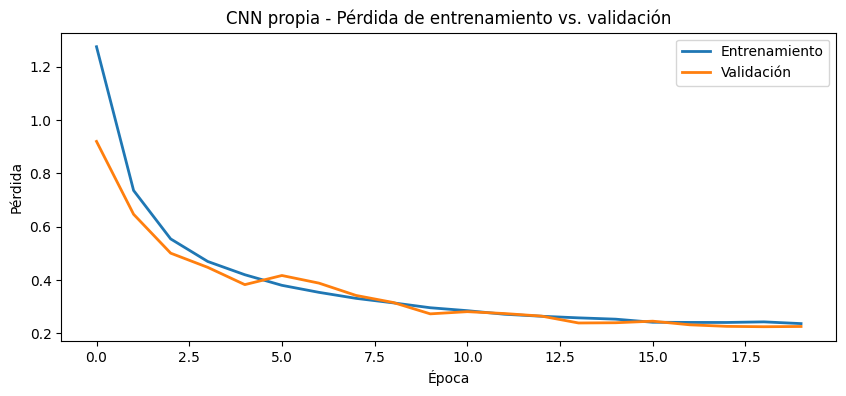

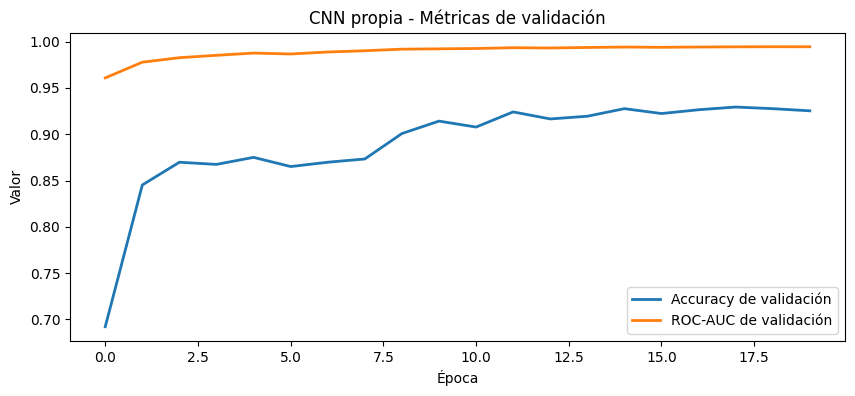

Diferencia final val_loss - train_loss: -0.0108


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Entrenamiento", color="tab:blue", linewidth=2)
plt.plot(history_scratch["val_loss"], label="Validación", color="tab:orange", linewidth=2)
plt.title("CNN propia - Pérdida de entrenamiento vs. validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy de validación", linewidth=2)
plt.plot(history_scratch["val_auc"], label="ROC-AUC de validación", linewidth=2)
plt.title("CNN propia - Métricas de validación")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

gap_final = history_scratch["val_loss"][-1] - history_scratch["train_loss"][-1]
print(f"Diferencia final val_loss - train_loss: {gap_final:.4f}")

**Interpretación:** Las pérdidas de entrenamiento y validación disminuyen de forma similar a lo largo de las 20 épocas y se mantienen cercanas durante la etapa final del entrenamiento. La pérdida de entrenamiento termina en **0.2367** y la de validación en **0.2259**, con una diferencia final de **−0.0108**. No se observa una separación progresiva entre ambas curvas, por lo que no se presentan señales claras de overfitting.

Por otro lado, las métricas de validación mejoran durante las primeras épocas y luego tienden a estabilizarse. Al finalizar el entrenamiento, el modelo alcanza un **accuracy de 0.9252** y un **ROC-AUC macro de 0.9944**.

### **5.4. Evaluación de la CNN en el conjunto de prueba**

La CNN se evalúa utilizando el conjunto de prueba, que contiene imágenes que no fueron utilizadas durante el entrenamiento. Para analizar su desempeño se consideran el accuracy, el ROC-AUC macro, las métricas por clase y la matriz de confusión.

In [ ]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
nombres_clases = [info["label"][str(i)] for i in range(num_classes)]

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC (macro, ovr): {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=nombres_clases, digits=4))

Test accuracy: 0.9263
Test ROC-AUC (macro, ovr): 0.9941

                                                                     precision    recall  f1-score   support

                                                           basophil     0.8761    0.8115    0.8426       244
                                                         eosinophil     0.9855    0.9824    0.9839       624
                                                       erythroblast     0.9636    0.9357    0.9494       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)     0.7952    0.8653    0.8288       579
                                                         lymphocyte     0.9247    0.9095    0.9170       243
                                                           monocyte     0.8958    0.8169    0.8545       284
                                                         neutrophil     0.9568    0.9655    0.9611       666
                                                           platelet   

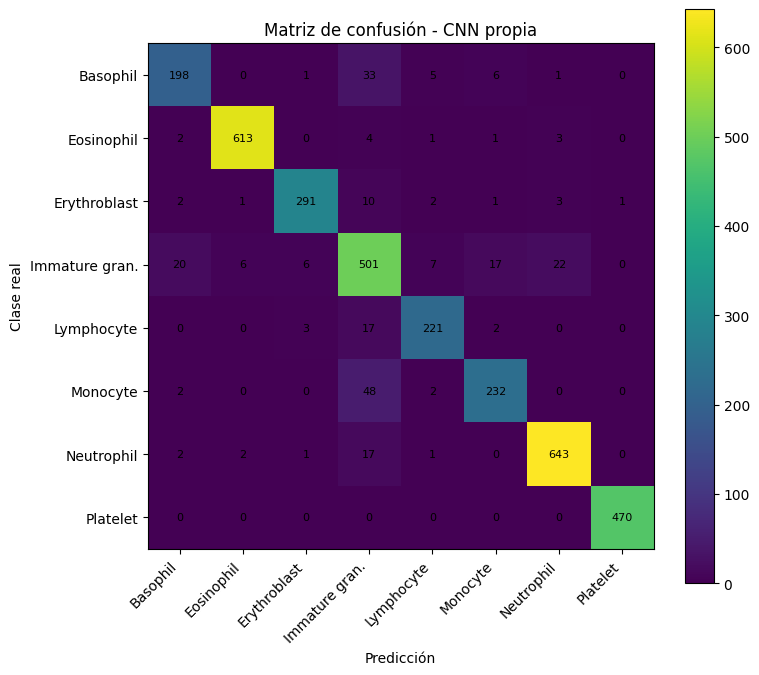

In [ ]:
cm = confusion_matrix(y_true, y_pred)

nombres_cortos = [
    "Basophil",
    "Eosinophil",
    "Erythroblast",
    "Immature gran.",
    "Lymphocyte",
    "Monocyte",
    "Neutrophil",
    "Platelet"
]

plt.figure(figsize=(8, 7))
plt.imshow(cm)

plt.title("Matriz de confusión - CNN propia")
plt.xlabel("Predicción")
plt.ylabel("Clase real")

plt.xticks(range(num_classes), nombres_cortos, rotation=45, ha="right")
plt.yticks(range(num_classes), nombres_cortos)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

plt.colorbar()
plt.tight_layout()
plt.show()

**Interpretación:** La CNN alcanza un **accuracy de 0.9263** y un **ROC-AUC macro de 0.9941** en el conjunto de prueba, mostrando un buen desempeño general en la clasificación de las 8 categorías.

Al observar las métricas por clase y la matriz de confusión, **platelet** presenta el mejor desempeño, con un recall de 1.0000 y un F1-score de 0.9989. Las mayores confusiones se concentran en la clase **immature granulocytes**, principalmente con basophil y neutrophil, y en **monocyte**, donde 45 imágenes fueron clasificadas como immature granulocytes. Estas diferencias muestran que aunque el rendimiento general es alto, algunas categorías presentan una mayor dificultad de clasificación.

## **6. Efecto del learning rate y scheduler**

El learning rate determina el tamaño de los pasos que realiza el optimizador al actualizar los parámetros del modelo. Un valor demasiado alto puede provocar un entrenamiento inestable, mientras que uno demasiado bajo puede hacer que el aprendizaje sea más lento.

Para observar su efecto, se entrena la misma arquitectura desde cero utilizando tres configuraciones:

* Learning rate alto: 1e-2, sin scheduler.
* Learning rate bajo: 1e-4, sin scheduler.
* Learning rate moderado: 1e-3, utilizando ReduceLROnPlateau.

En cada caso se comparan las pérdidas de entrenamiento y validación para analizar el comportamiento del modelo.

In [ ]:
def entrenar_con_lr(lr, usar_scheduler, epochs=10):
    modelo = CNNMejorada(in_channels=n_channels, num_classes=num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)

    scheduler = None
    if usar_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(modelo, train_loader, optimizer, criterion)

        modelo.eval()
        losses_val = []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device).long().squeeze(1)

                logits = modelo(x)
                loss = criterion(logits, y)
                losses_val.append(loss.item())

        val_loss = float(np.mean(losses_val))

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if scheduler is not None:
            scheduler.step(val_loss)

    return train_losses, val_losses

In [ ]:
train_alto, val_alto = entrenar_con_lr(lr=1e-2, usar_scheduler=False)

train_bajo, val_bajo = entrenar_con_lr(lr=1e-4, usar_scheduler=False)

train_scheduler, val_scheduler = entrenar_con_lr(lr=1e-3, usar_scheduler=True)

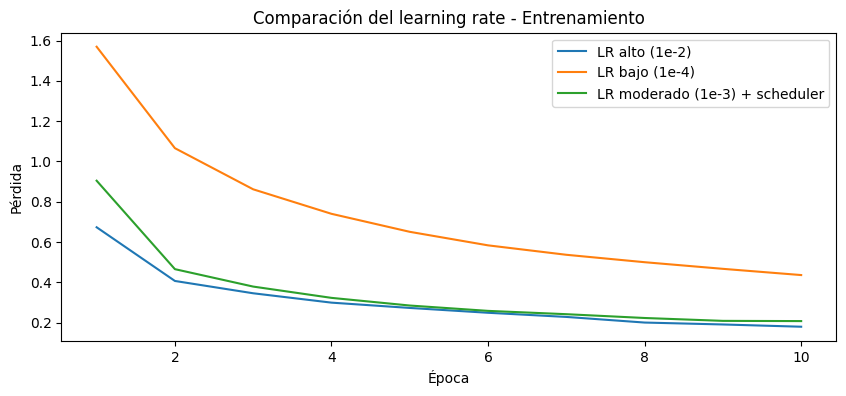

In [ ]:
epocas = range(1, 11)

plt.figure(figsize=(10, 4))

plt.plot(epocas, train_alto, label="LR alto (1e-2)")
plt.plot(epocas, train_bajo, label="LR bajo (1e-4)")
plt.plot(epocas, train_scheduler, label="LR moderado (1e-3) + scheduler")

plt.title("Comparación del learning rate - Entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.show()

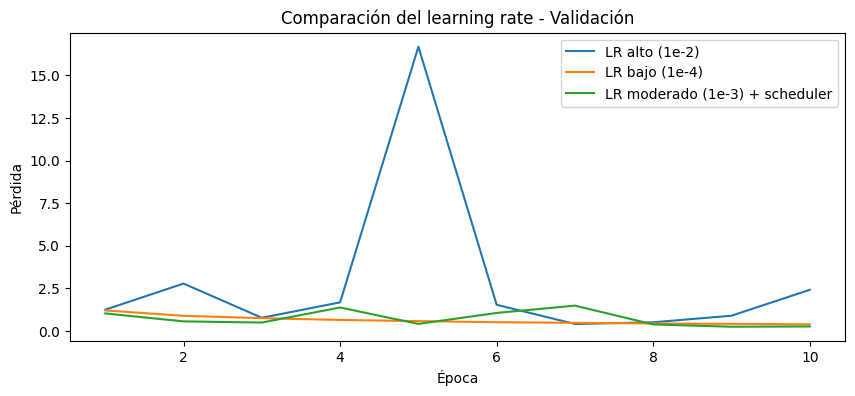

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(epocas, val_alto, label="LR alto (1e-2)")
plt.plot(epocas, val_bajo, label="LR bajo (1e-4)")
plt.plot(epocas, val_scheduler, label="LR moderado (1e-3) + scheduler")

plt.title("Comparación del learning rate - Validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.show()

In [ ]:
print(f"LR alto        | train final: {train_alto[-1]:.4f} | val final: {val_alto[-1]:.4f}")
print(f"LR bajo        | train final: {train_bajo[-1]:.4f} | val final: {val_bajo[-1]:.4f}")
print(f"LR + scheduler | train final: {train_scheduler[-1]:.4f} | val final: {val_scheduler[-1]:.4f}")

LR alto        | train final: 0.1806 | val final: 2.4225
LR bajo        | train final: 0.4368 | val final: 0.3944
LR + scheduler | train final: 0.2085 | val final: 0.2726


**Interpretación:** Los resultados muestran diferencias claras entre las tres configuraciones. Con el learning rate alto (1e-2), la pérdida de entrenamiento disminuye rápidamente, pero la pérdida de validación presenta fuertes oscilaciones, incluyendo un pico muy pronunciado durante el entrenamiento. Esto indica que un learning rate demasiado alto puede generar actualizaciones inestables y afectar el comportamiento del modelo sobre datos de validación.

Con el learning rate bajo (1e-4), las curvas son más estables, aunque el aprendizaje es más lento. Por su parte, la configuración con learning rate inicial de 1e-3 y scheduler logra reducir la pérdida con mayor rapidez y mantiene un comportamiento de validación más estable que el LR alto. Estos nos demuestra la importancia de elegir adecuadamente el learning rate y ajustarlo durante el entrenamiento.


## **7. Comparación de estrategias de Data Augmentation**

El data augmentation permite generar variaciones de las imágenes de entrenamiento mediante transformaciones aleatorias, con el objetivo de aumentar su diversidad sin incorporar nuevas muestras.

En este experimento se comparan tres configuraciones: sin aumento de datos, augmentation leve y augmentation fuerte. Las transformaciones se aplican únicamente al conjunto de entrenamiento, mientras que los conjuntos de validación y prueba se mantienen sin modificaciones.

In [ ]:
transform_sin_aug = T.Compose([
    T.ToTensor()
])

transform_aug_leve = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

transform_aug_fuerte = T.Compose([
    T.RandomRotation(degrees=25),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor()
])

def entrenar_con_transform(transform, epochs=10):
    dataset_train = DataClass(
        split="train",
        transform=transform,
        download=True
    )

    loader_train = DataLoader(
        dataset_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=(device.type == "cuda")
    )

    modelo = CNNMejorada(
        in_channels=n_channels,
        num_classes=num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(modelo.parameters(), lr=1e-3)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    for epoch in range(1, epochs + 1):
        train_one_epoch(
            modelo,
            loader_train,
            optimizer,
            criterion
        )

        modelo.eval()
        val_losses = []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device).long().squeeze(1)

                logits = modelo(x)
                val_losses.append(criterion(logits, y).item())

        val_loss = float(np.mean(val_losses))
        scheduler.step(val_loss)

    test_acc, test_auc, _, _, _ = evaluate(modelo, test_loader)

    return modelo, test_acc, test_auc

modelo_sin_aug, acc_sin_aug, auc_sin_aug = entrenar_con_transform(transform_sin_aug)
modelo_aug_leve, acc_aug_leve, auc_aug_leve = entrenar_con_transform(transform_aug_leve)
modelo_aug_fuerte, acc_aug_fuerte, auc_aug_fuerte = entrenar_con_transform(transform_aug_fuerte)

print(f"Sin augmentation   | test_acc={acc_sin_aug:.4f} | test_auc={auc_sin_aug:.4f}")
print(f"Augmentation leve  | test_acc={acc_aug_leve:.4f} | test_auc={auc_aug_leve:.4f}")
print(f"Augmentation fuerte| test_acc={acc_aug_fuerte:.4f} | test_auc={auc_aug_fuerte:.4f}")

Sin augmentation   | test_acc=0.8433 | test_auc=0.9895
Augmentation leve  | test_acc=0.8954 | test_auc=0.9932
Augmentation fuerte| test_acc=0.7381 | test_auc=0.9852


**Interpretación:** El augmentation leve obtuvo el mejor resultado de las tres configuraciones, con un accuracy de **0.8954** y un ROC-AUC de **0.9932**. En comparación, el modelo sin augmentation alcanzó un accuracy de **0.8433**, mientras que el augmentation fuerte redujo el accuracy hasta **0.7381**.

En este experimento, aplicar transformaciones moderadas ayudó al modelo a generalizar mejor, mientras que transformaciones más intensas perjudicaron su rendimiento. Esto muestra que aumentar la cantidad o intensidad de las transformaciones no necesariamente mejora los resultados y que su efecto depende de qué tanto se modifica la información original de las imágenes.

## **8. Transfer Learning con ResNet18**

En esta sección se utiliza **ResNet18**, una red previamente entrenada con ImageNet, para aplicar Transfer Learning a BloodMNIST. En lugar de entrenar toda la red desde cero, se aprovechan las características aprendidas previamente y se adapta la capa final para realizar la clasificación de las 8 clases del dataset.

El entrenamiento se realiza en dos etapas:

1. Se adaptan las imágenes al formato de entrada de ResNet18 y se congela inicialmente el backbone, entrenando únicamente la capa final de clasificación.
2. Posteriormente, se desbloquea **layer4** para realizar un ajuste fino (fine-tuning) de las últimas capas del modelo.

In [ ]:
import torchvision.models as models

normalize_imagenet = T.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=15),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    normalize_imagenet
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    normalize_imagenet
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=(device.type == "cuda"))
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))

In [ ]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

parametros_entrenables = sum(
    p.numel() for p in resnet.parameters()
    if p.requires_grad
)

print("Parámetros entrenables en la primera etapa:", parametros_entrenables)

Parámetros entrenables en la primera etapa: 4104


### **8.1. Primera etapa: entrenamiento de la capa de clasificación**

En la primera etapa se mantienen congelados los parámetros preentrenados de ResNet18 y se entrena únicamente la nueva capa de clasificación (fc) durante 6 épocas. De esta manera, la salida del modelo se adapta inicialmente a las 8 clases de BloodMNIST sin modificar las características aprendidas previamente por la red.

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

epochs = 6

history_tl_stage1 = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    # Calculamos la pérdida de validación para seguir el comportamiento del modelo
    resnet.eval()
    val_losses = []

    with torch.no_grad():
        for x, y in val_loader_tl:
            x = x.to(device)
            y = y.to(device).long().squeeze(1)

            logits = resnet(x)
            val_losses.append(criterion(logits, y).item())

    val_loss = float(np.mean(val_losses))

    val_acc, val_auc, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    scheduler.step(val_loss)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(
        f"Stage1 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage1 Epoch 01 | train_loss=1.0099 | val_loss=0.7736 | val_acc=0.7436 | val_auc=0.9644
Stage1 Epoch 02 | train_loss=0.6147 | val_loss=0.6155 | val_acc=0.7897 | val_auc=0.9715
Stage1 Epoch 03 | train_loss=0.5382 | val_loss=0.5688 | val_acc=0.8067 | val_auc=0.9733
Stage1 Epoch 04 | train_loss=0.5184 | val_loss=0.5863 | val_acc=0.7950 | val_auc=0.9729
Stage1 Epoch 05 | train_loss=0.4898 | val_loss=0.5640 | val_acc=0.8078 | val_auc=0.9736
Stage1 Epoch 06 | train_loss=0.4741 | val_loss=0.5290 | val_acc=0.8248 | val_auc=0.9750


### **8.2. Segunda etapa: fine-tuning de `layer4`**

En la segunda etapa se desbloquea **layer4**, además de mantener entrenable la capa fc, para ajustar las últimas características de ResNet18 al conjunto BloodMNIST. Para este proceso se utiliza un learning rate menor (1e-4), con el fin de realizar ajustes más pequeños sobre los pesos preentrenados.

In [ ]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [
    p for p in resnet.parameters()
    if p.requires_grad
]

optimizer = torch.optim.Adam(
    trainable_params,
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

epochs = 6

history_tl_stage2 = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    resnet.eval()
    val_losses = []

    with torch.no_grad():
        for x, y in val_loader_tl:
            x = x.to(device)
            y = y.to(device).long().squeeze(1)

            logits = resnet(x)
            val_losses.append(criterion(logits, y).item())

    val_loss = float(np.mean(val_losses))

    val_acc, val_auc, _, _, _ = evaluate(
        resnet,
        val_loader_tl
    )

    scheduler.step(val_loss)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_loss"].append(val_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(
        f"Stage2 Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Stage2 Epoch 01 | train_loss=0.3310 | val_loss=0.2991 | val_acc=0.8984 | val_auc=0.9939
Stage2 Epoch 02 | train_loss=0.2076 | val_loss=0.2440 | val_acc=0.9130 | val_auc=0.9943
Stage2 Epoch 03 | train_loss=0.1581 | val_loss=0.2063 | val_acc=0.9328 | val_auc=0.9963
Stage2 Epoch 04 | train_loss=0.1351 | val_loss=0.2194 | val_acc=0.9293 | val_auc=0.9959
Stage2 Epoch 05 | train_loss=0.1086 | val_loss=0.1730 | val_acc=0.9422 | val_auc=0.9972
Stage2 Epoch 06 | train_loss=0.0931 | val_loss=0.1729 | val_acc=0.9468 | val_auc=0.9970


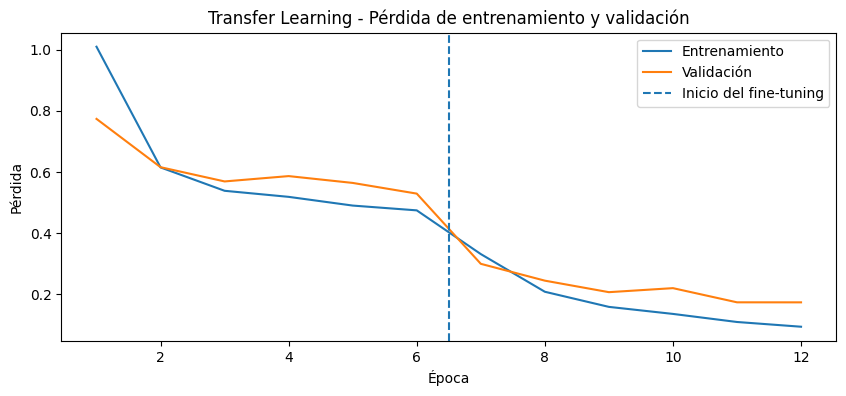

In [ ]:
train_loss_tl = (history_tl_stage1["train_loss"] + history_tl_stage2["train_loss"])
val_loss_tl = (history_tl_stage1["val_loss"] + history_tl_stage2["val_loss"])

epocas_tl = range(1, len(train_loss_tl) + 1)
plt.figure(figsize=(10, 4))
plt.plot(epocas_tl, train_loss_tl, label="Entrenamiento")
plt.plot(epocas_tl, val_loss_tl, label="Validación")
plt.axvline(x=6.5, linestyle="--", label="Inicio del fine-tuning")

plt.title("Transfer Learning - Pérdida de entrenamiento y validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.show()

**Interpretación:** Durante la primera etapa, en la que solo se entrena la capa de clasificación, la pérdida disminuye progresivamente y el accuracy de validación alcanza **0.8248**. Al iniciar el fine-tuning de layer4, se observa una mejora más marcada: al finalizar, el accuracy de validación llega a **0.9468** y el ROC-AUC a **0.9970**.

Las curvas de entrenamiento y validación mantienen una tendencia similar a lo largo del proceso. Aunque en las últimas épocas la pérdida de entrenamiento continúa disminuyendo más que la de validación, no se observa un aumento sostenido de esta última. Por ello, en estas 12 épocas no se aprecian señales claras de overfitting.

### **8.3. Evaluación del modelo con Transfer Learning**

In [ ]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, target_names=nombres_clases, digits=4))

Transfer learning | test_acc=0.9407 | test_auc=0.9962

                                                                     precision    recall  f1-score   support

                                                           basophil     0.8642    0.9385    0.8998       244
                                                         eosinophil     0.9888    0.9872    0.9880       624
                                                       erythroblast     0.9479    0.9357    0.9417       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)     0.8535    0.8756    0.8645       579
                                                         lymphocyte     0.9693    0.9095    0.9384       243
                                                           monocyte     0.9291    0.8310    0.8773       284
                                                         neutrophil     0.9531    0.9760    0.9644       666
                                                           platelet     

**Interpretación:** El modelo con Transfer Learning alcanza un accuracy de **0.9407** y un ROC-AUC macro de **0.9962** en el conjunto de prueba. El desempeño es alto en las diferentes clases, aunque se observan algunas diferencias entre ellas. Platelet presenta un recall de **0.9957**, mientras que monocyte obtiene **0.8310**, siendo una de las clases con mayor dificultad de clasificación.

### **8.4. Comparación de los modelos**

In [ ]:
print("Resumen de resultados en test (accuracy | ROC-AUC macro)")
print(f"CNN principal (20 épocas) | "f"acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"Experimento sin augmentation (10 ep.) | "f"acc={acc_sin_aug:.4f} | auc={auc_sin_aug:.4f}")
print(f"Augmentation leve (10 ep.) | "f"acc={acc_aug_leve:.4f} | auc={auc_aug_leve:.4f}")
print(f"Augmentation fuerte (10 ep.) | "f"acc={acc_aug_fuerte:.4f} | auc={auc_aug_fuerte:.4f}")
print(f"Transfer Learning (ResNet18) | "f"acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")

Resumen de resultados en test (accuracy | ROC-AUC macro)
CNN principal (20 épocas) | acc=0.9263 | auc=0.9941
Experimento sin augmentation (10 ep.) | acc=0.8433 | auc=0.9895
Augmentation leve (10 ep.) | acc=0.8954 | auc=0.9932
Augmentation fuerte (10 ep.) | acc=0.7381 | auc=0.9852
Transfer Learning (ResNet18) | acc=0.9407 | auc=0.9962


**Interpretación:** En esta ejecución, ResNet18 obtuvo un accuracy de **0.9407** y un ROC-AUC macro de **0.9962**, mientras que la CNN principal alcanzó **0.9263** y **0.9941**, respectivamente. Esto muestra que el modelo con Transfer Learning consiguió un mejor desempeño en ambas métricas.

Los resultados del experimento de data augmentation corresponden a entrenamientos de 10 épocas realizados bajo las mismas condiciones entre sí. Dentro de esta comparación, el augmentation leve obtuvo mejores resultados que entrenar sin augmentation o aplicar transformaciones más intensas.

## **9. Interpretabilidad con Grad-CAM**

Grad-CAM permite visualizar qué regiones de una imagen tienen mayor influencia en la predicción del modelo. En esta sección se aplica sobre ResNet18 para observar en qué zonas de las imágenes de BloodMNIST se concentra el modelo al realizar la clasificación.

Para facilitar la interpretación, se muestran tres elementos: la imagen original, el mapa de activación generado por Grad-CAM y la superposición de ambos.


In [ ]:
def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out
        out.register_hook(
            lambda grad: gradients.update({"value": grad})
        )

    handle = model.layer4.register_forward_hook(forward_hook)

    logits = model(image_tensor.unsqueeze(0))

    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]

    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.zeros(act.shape[1:], device=device)

    for i, w in enumerate(weights):
        cam += w * act[i]

    cam = torch.relu(cam)
    cam = cam - cam.min()

    if cam.max() > 0:
        cam = cam / cam.max()

    handle.remove()

    return cam.detach().cpu().numpy(), target_class

In [ ]:
def desnormalizar_imagen(x):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = x.cpu() * std + mean
    img = img.clamp(0, 1)

    return img.permute(1, 2, 0).numpy()

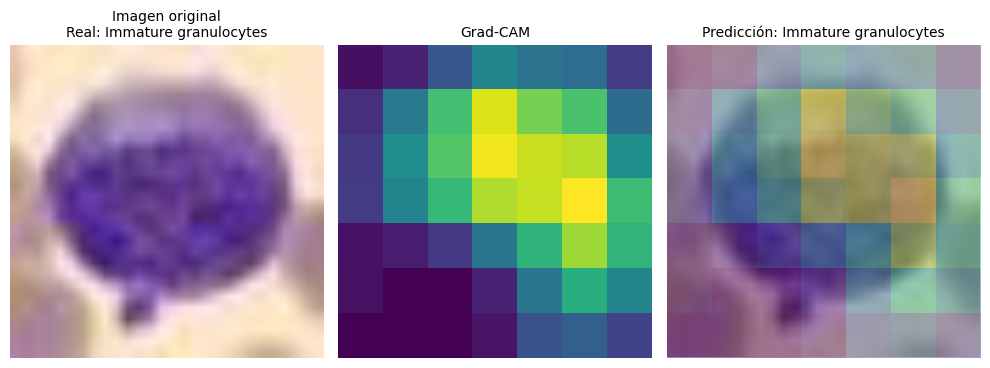

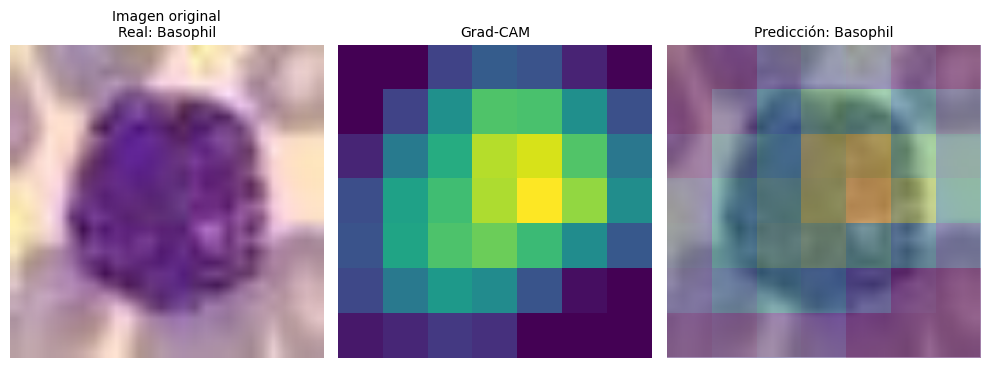

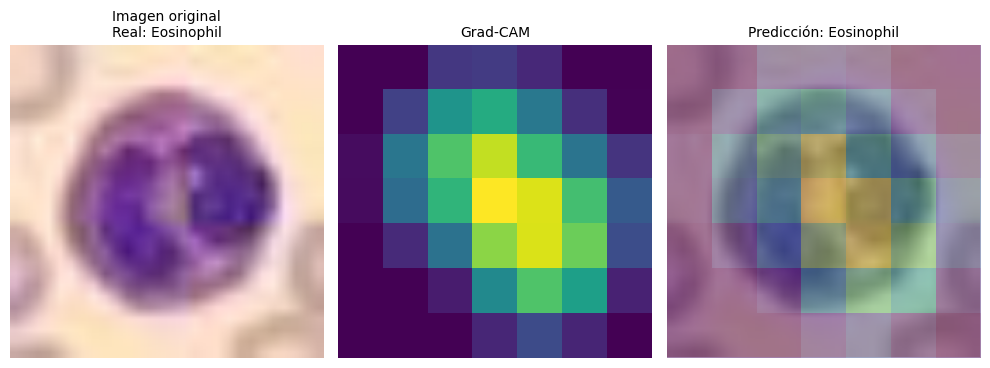

In [ ]:
nombres_cortos = [
    "Basophil",
    "Eosinophil",
    "Erythroblast",
    "Immature granulocytes",
    "Lymphocyte",
    "Monocyte",
    "Neutrophil",
    "Platelet"
]

for idx in [0, 1, 2]:
    x, y = test_dataset_tl[idx]

    cam, pred_class = grad_cam(resnet, x)

    img = desnormalizar_imagen(x)

    clase_real = nombres_cortos[int(y.item())]
    clase_predicha = nombres_cortos[pred_class]

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Imagen original\nReal: {clase_real}", fontsize=10)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam)
    plt.title("Grad-CAM", fontsize=10)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(
        cam,
        alpha=0.5,
        extent=(0, img.shape[1], img.shape[0], 0)
    )
    plt.title(f"Predicción: {clase_predicha}", fontsize=10)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

**Interpretación:** En los tres ejemplos, las regiones con mayor activación se concentran principalmente sobre la célula y no sobre el fondo de la imagen. Además, las clases predichas coinciden con las clases reales en los ejemplos mostrados. Esto permite observar que, para estos casos, el modelo está utilizando principalmente información localizada en la región de la célula para realizar sus predicciones.

## **10. Calibración de probabilidades y curvas ROC**

Además de evaluar el accuracy y el ROC-AUC, también es importante revisar qué tan confiables son las probabilidades que entrega el modelo. Para ello, analizo la calibración de las probabilidades mediante un diagrama de confiabilidad y el Expected Calibration Error (ECE).

También se construyen las curvas ROC para cada clase, utilizando el enfoque uno contra el resto (one-vs-rest), para observar con mayor detalle la capacidad del modelo para distinguir cada tipo de célula.

### **10.1. Calibración de probabilidades**

ECE (Expected Calibration Error): 0.0261


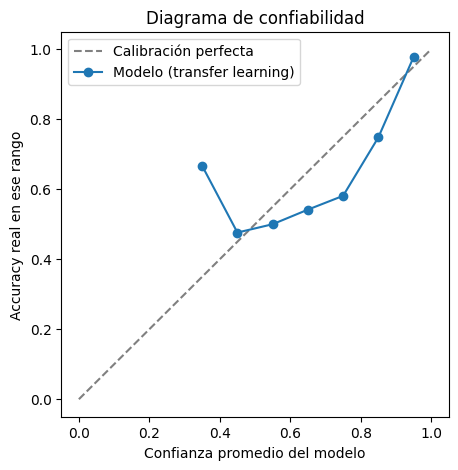

In [ ]:
def reliability_diagram(y_true, y_prob_max, y_pred, n_bins=10):
    # y_prob_max: probabilidad que el modelo le dio a la clase que predijo
    # (la "confianza" de la predicción).
    bins = np.linspace(0, 1, n_bins + 1)
    bin_acc = []
    bin_conf = []
    bin_counts = []

    correctas = (y_pred == y_true).astype(float)

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (y_prob_max > lo) & (y_prob_max <= hi)
        if mask.sum() == 0:
            bin_acc.append(np.nan)
            bin_conf.append(np.nan)
            bin_counts.append(0)
            continue
        bin_acc.append(correctas[mask].mean())
        bin_conf.append(y_prob_max[mask].mean())
        bin_counts.append(mask.sum())

    bin_counts = np.array(bin_counts)
    ece = 0.0
    for acc_b, conf_b, n_b in zip(bin_acc, bin_conf, bin_counts):
        if n_b == 0:
            continue
        ece += (n_b / len(y_true)) * abs(acc_b - conf_b)

    return bins, bin_acc, bin_conf, ece

y_prob_max_tl = y_prob_tl.max(axis=1)
bins, bin_acc, bin_conf, ece = reliability_diagram(y_true_tl, y_prob_max_tl, y_pred_tl)

print(f"ECE (Expected Calibration Error): {ece:.4f}")

centros = (bins[:-1] + bins[1:]) / 2
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
plt.plot(centros, bin_acc, marker="o", label="Modelo (transfer learning)")
plt.xlabel("Confianza promedio del modelo")
plt.ylabel("Accuracy real en ese rango")
plt.title("Diagrama de confiabilidad")
plt.legend()
plt.show()

**Interpretación:** El modelo obtuvo un ECE de **0.0261**, lo que indica que, en promedio, existe una diferencia pequeña entre la confianza de sus predicciones y la proporción real de aciertos. En el diagrama se observan algunas desviaciones respecto a la línea de calibración perfecta, especialmente en ciertos rangos de confianza intermedia. Sin embargo, en los niveles de confianza más altos, donde se concentra gran parte de las predicciones, la curva se aproxima a la diagonal. El modelo presenta una calibración adecuada, aunque no perfecta.

### **10.2. Curvas ROC por clase**

Para complementar el ROC-AUC macro, se calculan las curvas ROC de cada clase mediante el enfoque **uno contra el resto** (one-vs-rest). De esta forma, cada clase se evalúa frente al conjunto de las demás y se obtiene su AUC individual.

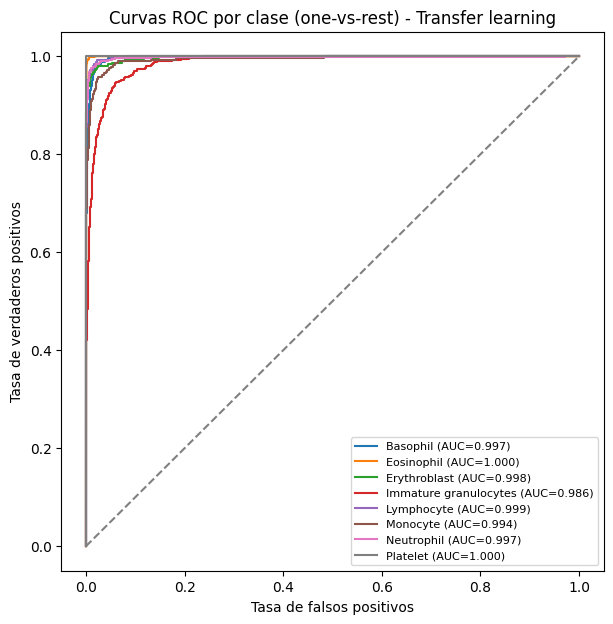

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(y_true_tl, classes=list(range(num_classes)))

plt.figure(figsize=(7, 7))
for c in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, c], y_prob_tl[:, c])
    auc_c = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{nombres_cortos[c]} (AUC={auc_c:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC por clase (one-vs-rest) - Transfer learning")
plt.legend(fontsize=8)
plt.show()


**Interpretación:** Las curvas ROC se mantienen próximas a la esquina superior izquierda, lo que indica una buena capacidad del modelo para distinguir cada clase frente al resto. Los valores de AUC son altos en las ocho categorías, desde **0.986** para *Immature granulocytes* hasta **1.000** para *Eosinophil y Platelet*. Aunque *Immature granulocytes* presenta el AUC más bajo, su valor sigue siendo elevado. Estos resultados son consistentes con el ROC-AUC macro de **0.9962** obtenido por el modelo.

## **11. Guardar los modelos entrenados**

Finalmente, guardo los pesos de la CNN principal y del modelo ResNet18 entrenado mediante Transfer Learning para poder reutilizarlos sin necesidad de repetir el entrenamiento.

In [ ]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_blood_scratch.pth")
torch.save(resnet.state_dict(), "models/resnet_blood_transfer.pth")

print("Modelos guardados correctamente.")

Modelos guardados correctamente.


## **12. Conclusiones**

A partir de los experimentos realizados con BloodMNIST, se obtuvieron las siguientes conclusiones:

1. **Arquitectura de la CNN:** La CNN propia se adaptó al problema multiclase utilizando tres bloques convolucionales con **32, 64 y 128 filtros**, además de BatchNorm y Dropout. Con esta configuración, el modelo principal alcanzó un accuracy de **0.9263** y un ROC-AUC macro de **0.9941** en el conjunto de prueba.

2. **Learning rate y scheduler:** El experimento mostró que el learning rate influye directamente en la estabilidad del entrenamiento. Con un valor alto (1e-2), la pérdida de validación presentó oscilaciones y un pico pronunciado, mientras que un valor bajo (1e-4) produjo un aprendizaje más lento. La configuración moderada (1e-3) con scheduler presentó un comportamiento más estable. En el entrenamiento de la CNN principal también se utilizaron weight_decay y gradient clipping para regularizar y estabilizar el proceso.

3. **Data augmentation:** Dentro del experimento realizado durante 10 épocas, el augmentation leve obtuvo el mejor resultado, con un accuracy de **0.8954** y un ROC-AUC de **0.9932**. Sin augmentation se obtuvo **0.8433** y **0.9895**, mientras que el augmentation fuerte alcanzó **0.7381** y **0.9852**. Esto muestra que transformaciones moderadas pueden favorecer la generalización, mientras que transformaciones demasiado intensas pueden alterar información relevante de las imágenes.

4. **Cambio de dataset:** El uso de BloodMNIST requirió adaptar el pipeline de un problema binario en escala de grises a una clasificación multiclase de 8 categorías con imágenes RGB. Esto implicó modificar la entrada de la CNN, la salida del clasificador y el cálculo de métricas para trabajar con múltiples clases.

5. **Transfer Learning e interpretabilidad:** ResNet18 alcanzó un accuracy de **0.9407** y un ROC-AUC macro de **0.9962** en test. En los ejemplos analizados con Grad-CAM, las regiones de mayor activación se concentraron principalmente sobre las células, lo que permitió observar qué zonas tuvieron mayor influencia en las predicciones.

6. **Calibración y curvas ROC:** El modelo ResNet18 obtuvo un ECE de **0.0261**, indicando una diferencia promedio pequeña entre la confianza de sus predicciones y los aciertos observados. Los AUC por clase se encontraron entre **0.986** y **1.000**, con los valores más altos en Eosinophil y Platelet (1.000).

7. **Revisión de overfitting:** Las curvas de pérdida de entrenamiento y validación de la CNN principal siguieron una evolución similar y finalizaron con valores muy próximos. En Transfer Learning tampoco se observó un aumento sostenido de la pérdida de validación mientras disminuía la de entrenamiento. Por ello, en los entrenamientos realizados no se observan señales claras de overfitting.